<a href="https://colab.research.google.com/github/santhoshnukala/santo-25/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(102, 2)
Accuracy:  0.8095238095238095


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'Negative'

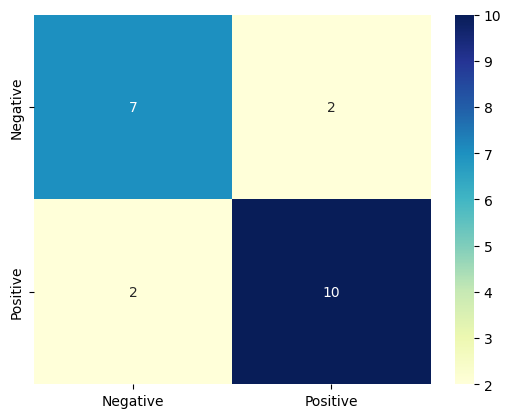

In [3]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

nltk.download('stopwords')


data = pd.read_csv(
    '/content/Restaurant_Reviews.tsv',
    delimiter='\t',
    quoting=3
)
print(data.shape)   # (1000, 2)
data.head()

def preprocess_text(text):
    # Remove everything except letters
    review = re.sub('[^a-zA-Z]', ' ', text)
    # Lowercase
    review = review.lower()
    # Split into words
    words = review.split()
    # Remove stopwords (keep 'not' for negation!)
    stop_words = set(stopwords.words('english'))
    stop_words.discard('not')
    words = [w for w in words if w not in stop_words]
    # Stem each word
    ps = PorterStemmer()
    words = [ps.stem(w) for w in words]
    return ' '.join(words)

corpus = [preprocess_text(review) for review in data['Review']]


cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:, 1].values   # labels (0 or 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
# X_train: 800 samples, X_test: 200 samples


classifier = MultinomialNB(alpha=0.2)   # alpha=0.2 is best after tuning
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='YlGnBu',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])


def predict_sentiment(text):
    preprocessed = preprocess_text(text)
    features = cv.transform([preprocessed]).toarray()
    result = classifier.predict(features)
    return "Positive" if result[0] == 1 else "Negative"

predict_sentiment("The food was absolutely wonderful!")  # → Positive
predict_sentiment("Worst experience ever, rude staff.")  # → Negative